<a href="https://colab.research.google.com/github/aniketkumar112sonu-ui/fraud-detection-risk-engine/blob/main/notebook_02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/paysim dataset.csv")

print(df.shape)

(3060599, 11)


# **UNIVARIATE DATA ANALYSIS**

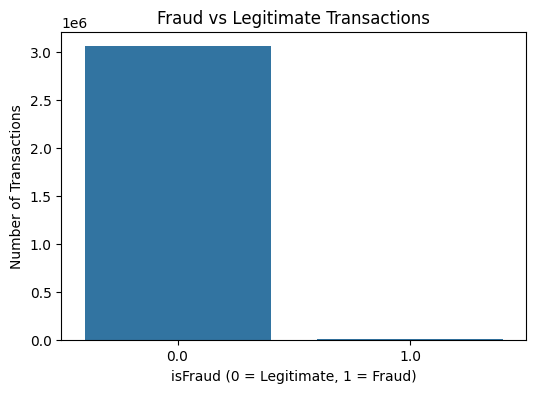

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fraud vs legitimate
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="isFraud")
plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("isFraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()





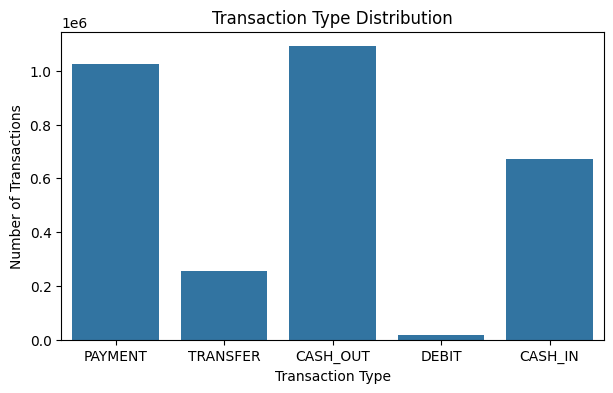

In [3]:
# 2. Transaction types
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="type")
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

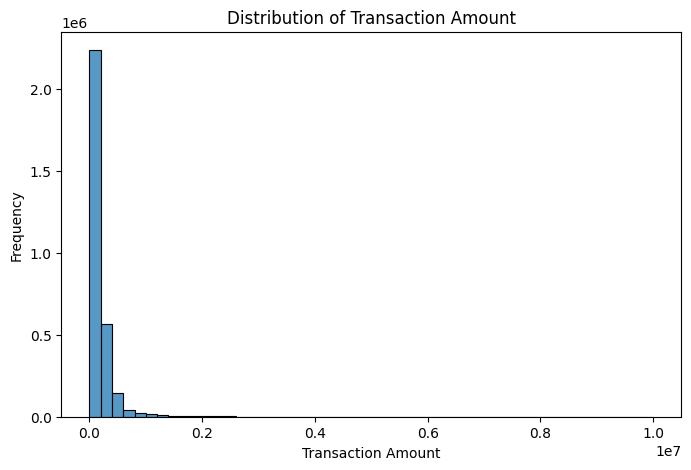

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(df["amount"], bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

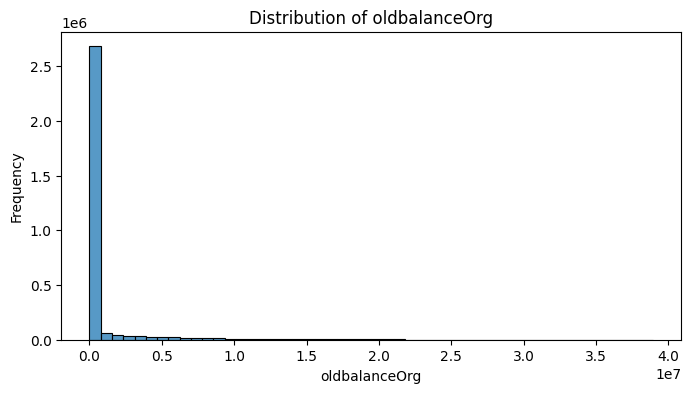

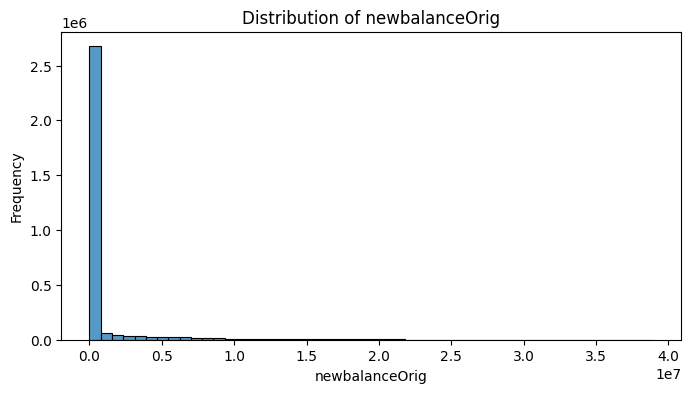

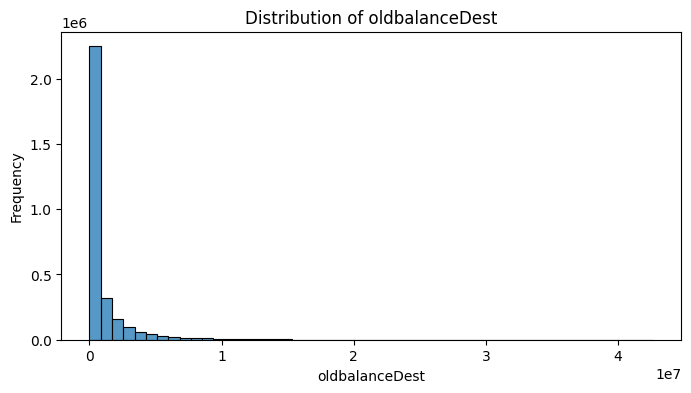

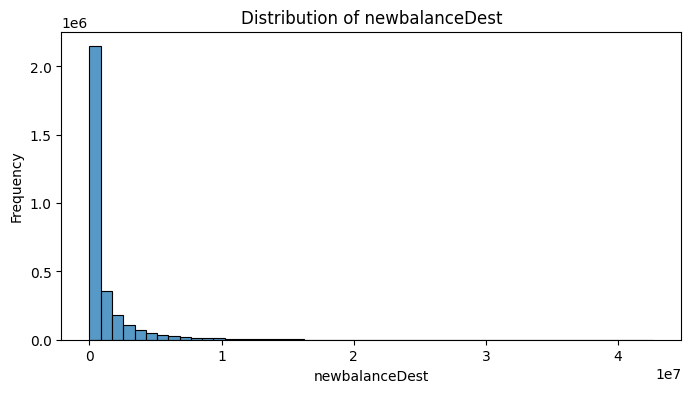

In [6]:
balance_cols = [
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

for col in balance_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

TIME ANALYSIS

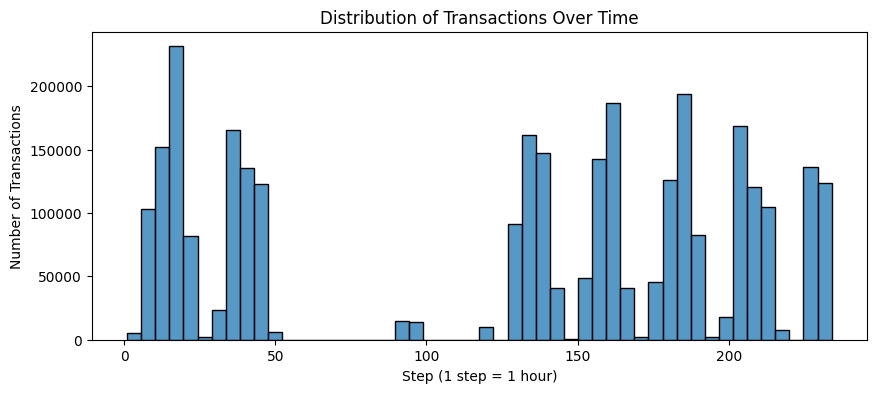

In [7]:
plt.figure(figsize=(10, 4))

sns.histplot(df["step"], bins=50)

plt.title("Distribution of Transactions Over Time")
plt.xlabel("Step (1 step = 1 hour)")
plt.ylabel("Number of Transactions")
plt.show()

# **BIVARIATE ANALYSIS**

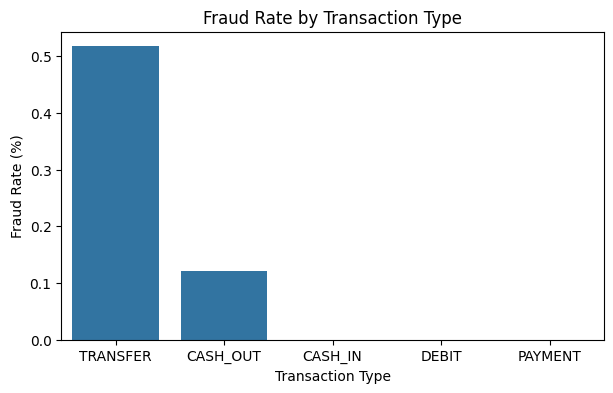

In [4]:
# 3. Fraud rate by transaction type
fraud_rate = df.groupby("type")["isFraud"].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.show()

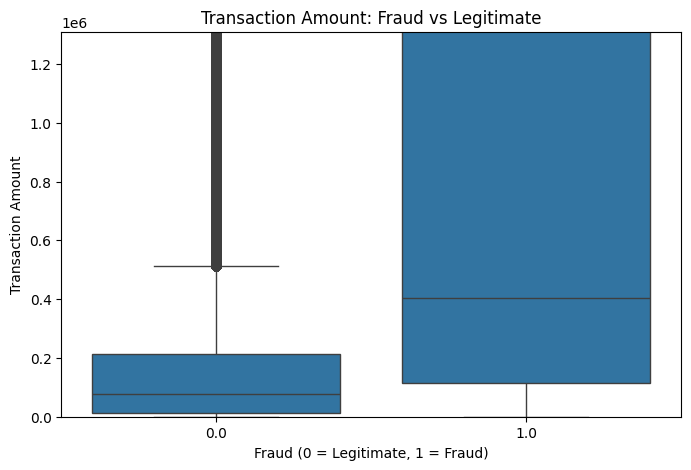

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

# Ignore extreme outliers for better visualization
plt.ylim(0, df["amount"].quantile(0.99))

plt.title("Transaction Amount: Fraud vs Legitimate")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

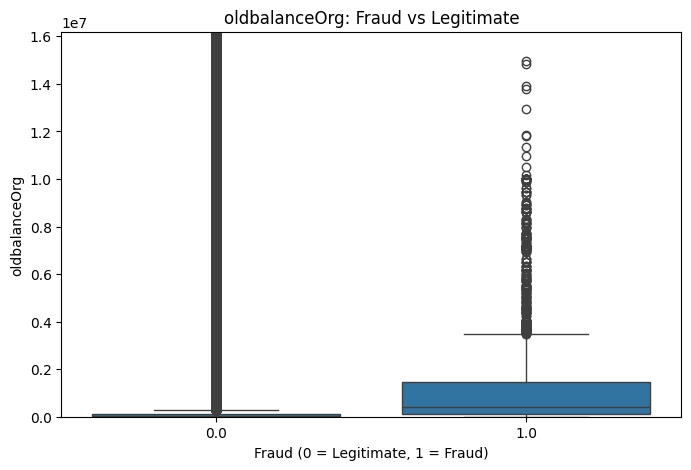

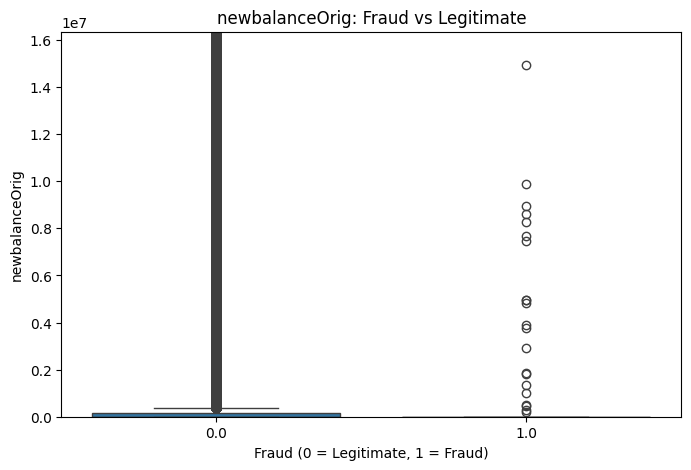

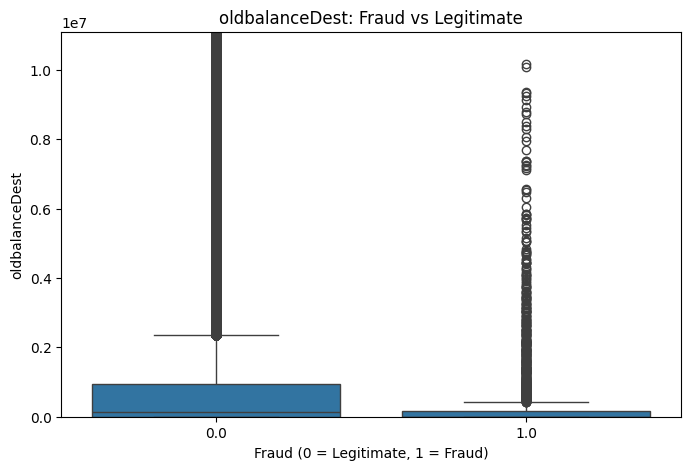

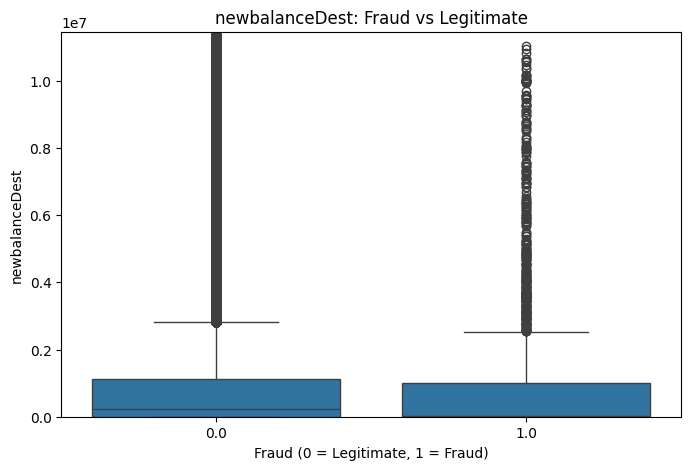

In [10]:
#Balance feature vs fraud

balance_cols = [
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

for col in balance_cols:
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=df, x="isFraud",y=col)

    plt.ylim(0, df[col].quantile(0.99))

    plt.title(f"{col}: Fraud vs Legitimate")
    plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
    plt.ylabel(col)

    plt.show()

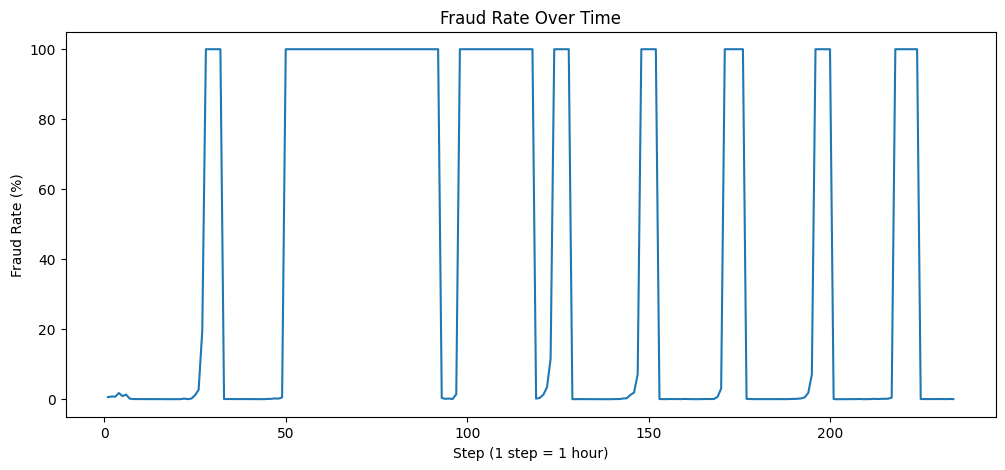

In [11]:
#Fraud rate over time

fraud_by_step = df.groupby("step")["isFraud"].mean() * 100

plt.figure(figsize=(12, 5))

plt.plot(fraud_by_step.index, fraud_by_step.values)

plt.title("Fraud Rate Over Time")
plt.xlabel("Step (1 step = 1 hour)")
plt.ylabel("Fraud Rate (%)")

plt.show()

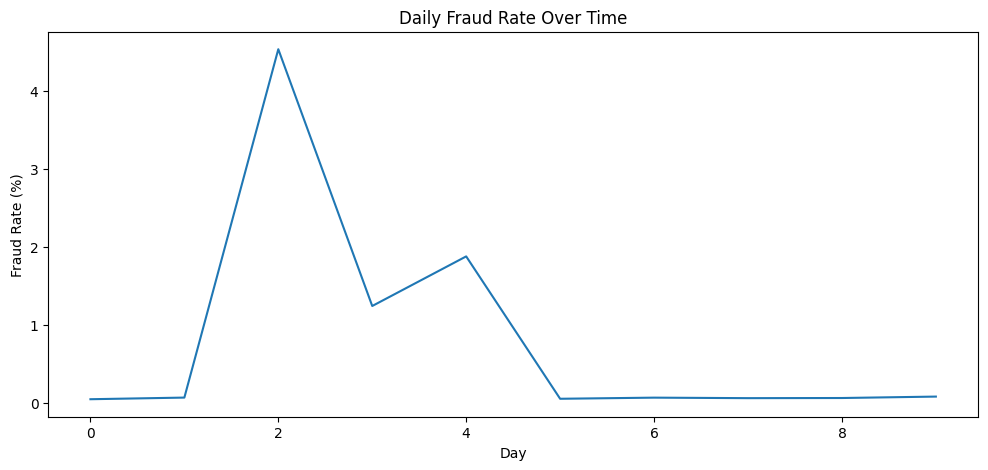

In [13]:
#Daily fraud rate

df["day"] = df["step"] // 24
daily_fraud_rate = df.groupby("day")["isFraud"].mean() * 100

plt.figure(figsize=(12, 5))

plt.plot(daily_fraud_rate.index, daily_fraud_rate.values)

plt.title("Daily Fraud Rate Over Time")
plt.xlabel("Day")
plt.ylabel("Fraud Rate (%)")

plt.show()

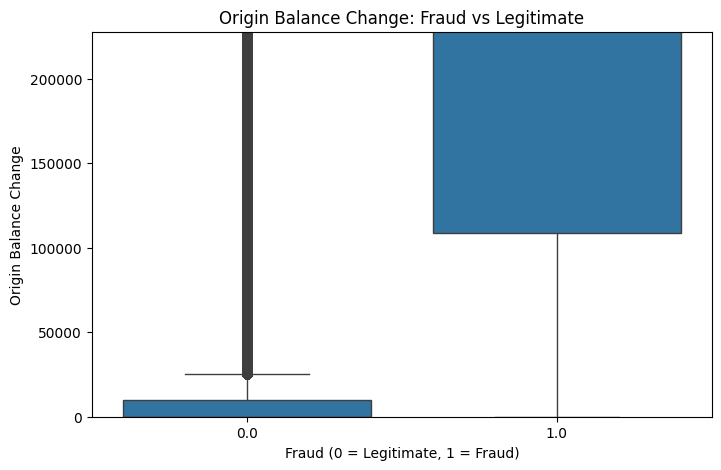

In [14]:
#Balance change vs fraud

df["orig_balance_change"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

plt.figure(figsize=(8, 5))

sns.boxplot(data=df,x="isFraud", y="orig_balance_change")

plt.ylim(0, df["orig_balance_change"].quantile(0.99))

plt.title("Origin Balance Change: Fraud vs Legitimate")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Origin Balance Change")

plt.show()

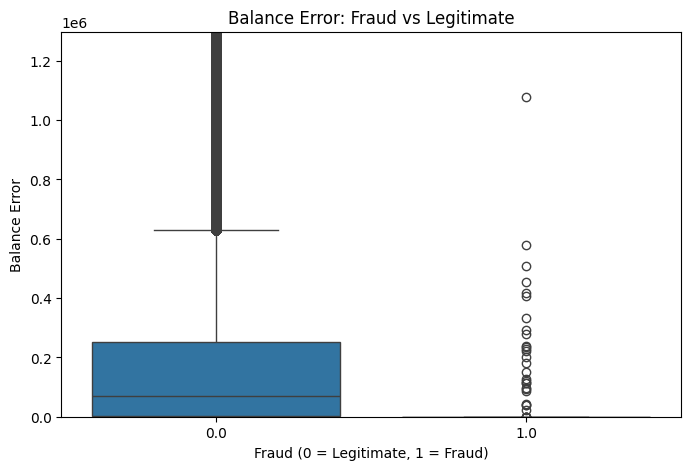

In [15]:
#Balance error vs fraud

df["orig_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

df["orig_error"] = df["amount"] - df["orig_balance_change"]

plt.figure(figsize=(8, 5))

sns.boxplot(data=df,x="isFraud",y="orig_error")

plt.ylim(df["orig_error"].quantile(0.01),df["orig_error"].quantile(0.99))

plt.title("Balance Error: Fraud vs Legitimate")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Balance Error")

plt.show()

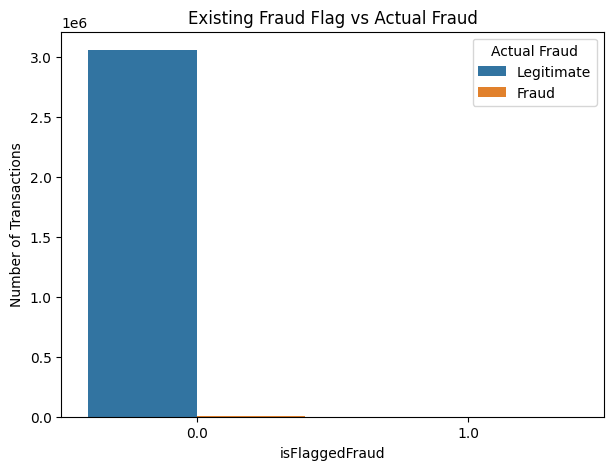

In [16]:
#Existing flag vs actual Fraud

plt.figure(figsize=(7, 5))

sns.countplot(data=df,x="isFlaggedFraud",hue="isFraud")

plt.title("Existing Fraud Flag vs Actual Fraud")
plt.xlabel("isFlaggedFraud")
plt.ylabel("Number of Transactions")
plt.legend(title="Actual Fraud",labels=["Legitimate", "Fraud"])

plt.show()

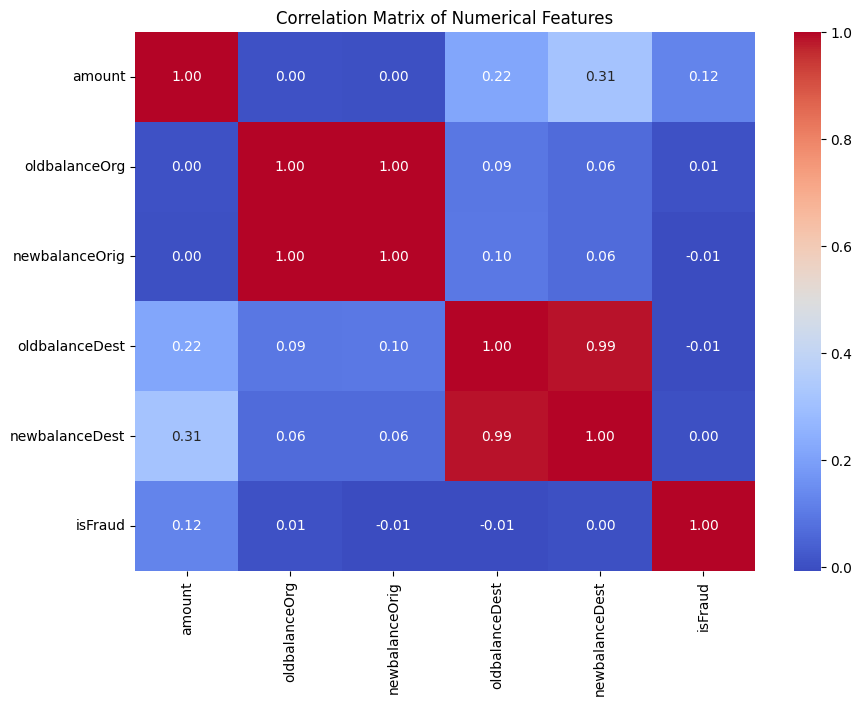

In [17]:
#Correlation analysis

numeric_cols = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]

plt.figure(figsize=(10, 7))

sns.heatmap(df[numeric_cols].corr(),annot=True,fmt=".2f",cmap="coolwarm")

plt.title("Correlation Matrix of Numerical Features")
plt.show()